---
tags: [tutorial]
---

# Controlling Gates and Sub-Kernels with `qmc.control`

*(intro paragraph — to be written)*

In [1]:
# Install the latest Qamomile from pip.
# !pip install qamomile

In [2]:
import math

import qamomile.circuit as qmc

## 1. The minimal example: controlled-RX

The smallest useful application of `qmc.control` is wrapping a
single built-in rotation. `qmc.rx(q, angle)` is a one-qubit
gate; passing it to `qmc.control` produces a two-qubit
controlled-RX.

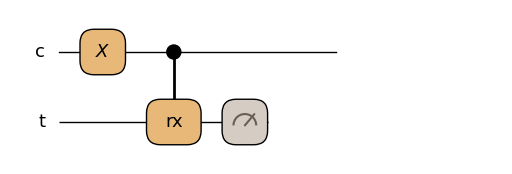

In [3]:
@qmc.qkernel
def crx_demo() -> qmc.Bit:
    c = qmc.qubit(name="c")
    t = qmc.qubit(name="t")
    # Drive the control to |1> so the controlled rotation fires.
    c = qmc.x(c)
    crx = qmc.control(qmc.rx)
    c, t = crx(c, t, angle=math.pi)
    return qmc.measure(t)


crx_demo.draw()

Three things to notice at the call site:

- `qmc.control(qmc.rx)` is evaluated at *decoration time*. The
  returned `ControlledGate` (here bound to `crx`) is a reusable
  value; you can stash it in a variable and call it multiple
  times.
- When you call `crx(c, t, angle=...)`, the control qubits come
  first as positional arguments, then the targets, then any
  classical keyword arguments. The order mirrors the wrapped
  `qmc.rx(q, angle)` signature with one extra control prefixed.
- The keyword name for the classical parameter is whatever the
  wrapped function uses (`angle` for `qmc.rx`, `theta` for
  `qmc.p`, etc.) — `qmc.control` does not rename it.

## 2. Two modes at a glance

`qmc.control` has two modes. Which one you are in is decided
entirely by the type you pass for `num_controls`: a Python
`int` puts you in *concrete* mode, a `qmc.UInt` handle (or any
`UInt` expression like `n - 1`) puts you in *symbolic* mode.
Everything else about the call follows from that choice.

| Aspect | Concrete | Symbolic |
| --- | --- | --- |
| `num_controls=` | Python `int` (default `1`) | `qmc.UInt` handle, or any `UInt` expression |
| Control argument(s) | one or more positional args (`Qubit`, `VectorView`, or `Vector[Qubit]`) whose qubit counts sum to `num_controls` | exactly one `Vector[Qubit]` or `VectorView` *pool* |
| `controlled_indices=` | not accepted | optional — picks which slots of the pool are active |
| Control count resolved at | decoration time | transpile time (from `bindings`) |

A short decision rule: reach for *concrete* mode when the
control count is a literal you know while writing the qkernel
and you want to name each control qubit individually. Reach for
*symbolic* mode when the count is a kernel parameter (or an
expression over one — `num_controls=n - 1` is the textbook
multi-controlled form).

Most of `qmc.control`'s features (`power=`, default values,
classical-kwarg reordering, sub-kernels that take
`Vector[Qubit]`, ...) behave identically in both modes; Section
3 collects those. The handful of features that are mode-specific
are split between Section 4 (concrete only) and Section 5
(symbolic only).

## 3. Patterns that work in BOTH modes

*(to be written)*

### 3.1 Wrapping any callable

*(to be written)*

### 3.2 Sub-kernel taking `Vector[Qubit]`

*(to be written)*

### 3.3 Default values from `@qmc.qkernel` signatures

*(to be written)*

### 3.4 Classical keyword arguments in any order

*(to be written)*

### 3.5 Controlling `U^k` with `power=`

*(to be written)*

## 4. Concrete-mode-only patterns

*(to be written)*

### 4.1 Multiple separate positional control args (CCX style)

*(to be written)*

### 4.2 Mixing scalar Qubit and `VectorView` controls

*(to be written)*

## 5. Symbolic-mode-only patterns

*(to be written)*

### 5.1 `num_controls = n` over a whole pool

*(to be written)*

### 5.2 Canonical `n - 1` multi-controlled form

*(to be written)*

### 5.3 Selecting a subset with `controlled_indices=`

*(to be written)*

### 5.4 `controlled_indices` with `UInt` entries

*(to be written)*

## 6. Patterns that don't work

*(to be written — uses an `expect_error` helper so each rejected
shape doubles as a regression check)*

## 7. Summary

*(to be written)*